<a href="https://colab.research.google.com/github/Samia23348/credit-banq/blob/main/deep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


Charger le dataset tabulaire

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("Classes :", data.target_names)

Dimensions de X : (569, 30)
Dimensions de y : (569,)
Classes : ['malignant' 'benign']


Préparer les données

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : torch.Size([455, 30])
Test : torch.Size([114, 30])


MLP avec nn.Sequential

In [4]:
model_seq = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
).to(device)

print(model_seq)

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


MLP avec classe personnalisée

In [5]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP(X_train.shape[1]).to(device)
print(model)

MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


Inspecter les paramètres

In [6]:
for name, param in model.named_parameters():
    print(name, param.shape)

fc1.weight torch.Size([64, 30])
fc1.bias torch.Size([64])
fc2.weight torch.Size([32, 64])
fc2.bias torch.Size([32])
fc3.weight torch.Size([2, 32])
fc3.bias torch.Size([2])


In [7]:
print(model.state_dict().keys())

odict_keys(['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias'])


Initialisation Xavier

In [8]:
def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_xavier)
print("Initialisation Xavier appliquée.")

Initialisation Xavier appliquée.


Entraîner le modèle

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)

    print(f"Epoch {epoch+1}/{epochs} - Loss : {total_loss:.4f}")

Epoch 1/50 - Loss : 7.3390
Epoch 2/50 - Loss : 3.6670
Epoch 3/50 - Loss : 2.1316
Epoch 4/50 - Loss : 1.5130
Epoch 5/50 - Loss : 1.1148
Epoch 6/50 - Loss : 0.9612
Epoch 7/50 - Loss : 0.8543
Epoch 8/50 - Loss : 0.7580
Epoch 9/50 - Loss : 0.6827
Epoch 10/50 - Loss : 0.6155
Epoch 11/50 - Loss : 0.6452
Epoch 12/50 - Loss : 0.5281
Epoch 13/50 - Loss : 0.4652
Epoch 14/50 - Loss : 0.4497
Epoch 15/50 - Loss : 0.3966
Epoch 16/50 - Loss : 0.3687
Epoch 17/50 - Loss : 0.3577
Epoch 18/50 - Loss : 0.3219
Epoch 19/50 - Loss : 0.2988
Epoch 20/50 - Loss : 0.2836
Epoch 21/50 - Loss : 0.2815
Epoch 22/50 - Loss : 0.2400
Epoch 23/50 - Loss : 0.2440
Epoch 24/50 - Loss : 0.2233
Epoch 25/50 - Loss : 0.1976
Epoch 26/50 - Loss : 0.1877
Epoch 27/50 - Loss : 0.1873
Epoch 28/50 - Loss : 0.1726
Epoch 29/50 - Loss : 0.1499
Epoch 30/50 - Loss : 0.1399
Epoch 31/50 - Loss : 0.1821
Epoch 32/50 - Loss : 0.1235
Epoch 33/50 - Loss : 0.1209
Epoch 34/50 - Loss : 0.1102
Epoch 35/50 - Loss : 0.1001
Epoch 36/50 - Loss : 0.0971
E

Afficher la courbe de perte

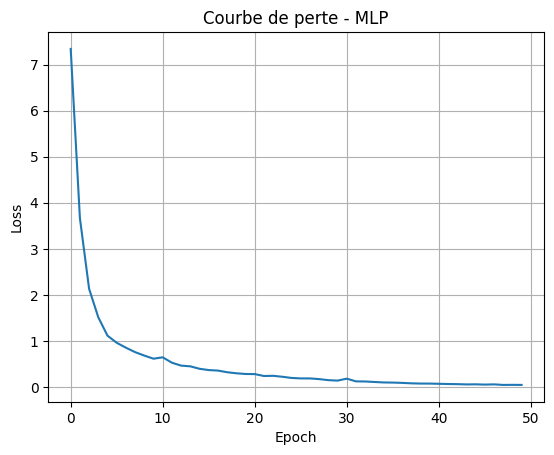

In [10]:
plt.plot(losses)
plt.title("Courbe de perte - MLP")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

Évaluer le modèle

In [11]:
model.eval()

with torch.no_grad():
    outputs = model(X_test.to(device))
    predictions = torch.argmax(outputs, dim=1).cpu()

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)

print("\nRapport de classification :")
print(classification_report(y_test, predictions))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, predictions))

Accuracy : 0.9649122807017544
Precision : 0.9857142857142858
Recall : 0.9583333333333334
F1-score : 0.971830985915493

Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114


Matrice de confusion :
[[41  1]
 [ 3 69]]


Sauvegarder le modèle

In [12]:
torch.save(model.state_dict(), "meilleur_modele_mlp.pth")
print("Modèle sauvegardé.")

Modèle sauvegardé.


Recharger le modèle

In [13]:
loaded_model = MLP(X_train.shape[1]).to(device)
loaded_model.load_state_dict(torch.load("meilleur_modele_mlp.pth"))
loaded_model.eval()

print("Modèle rechargé avec succès.")

Modèle rechargé avec succès.


Dans cette première partie, nous avons utilisé un MLP pour résoudre un problème de classification tabulaire sur le dataset Breast Cancer Wisconsin.
Les données ont été normalisées afin de faciliter l’apprentissage du modèle.
Le modèle a été implémenté avec PyTorch en utilisant une classe personnalisée héritant de nn.Module.
Les résultats obtenus montrent que le MLP est capable d’apprendre efficacement les relations entre les variables numériques du dataset.
Cependant, ses performances dépendent fortement du prétraitement, du choix des hyperparamètres et de l’initialisation des poids.

**Partie II — CNN sur Fashion-MNIST**

In [14]:
import torchvision
import torchvision.transforms as transforms

Corrélation 2D manuelle

In [15]:
def corr2d(X, K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()

    return Y

In [16]:
X = torch.tensor([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=torch.float32)

K = torch.tensor([
    [1, 0],
    [0, -1]
], dtype=torch.float32)

print(corr2d(X, K))

tensor([[-4., -4.],
        [-4., -4.]])


MaxPooling manuel

In [17]:
def max_pool2d(X, pool_size):
    h, w = pool_size
    Y = torch.zeros((X.shape[0] // h, X.shape[1] // w))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = X[i*h:i*h+h, j*w:j*w+w].max()

    return Y

In [18]:
X_pool = torch.tensor([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 1],
    [3, 4, 5, 6]
], dtype=torch.float32)

print(max_pool2d(X_pool, (2, 2)))

tensor([[6., 4.],
        [7., 8.]])


AveragePooling manuel

In [19]:
def avg_pool2d(X, pool_size):
    h, w = pool_size
    Y = torch.zeros((X.shape[0] // h, X.shape[1] // w))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = X[i*h:i*h+h, j*w:j*w+w].mean()

    return Y

In [20]:
print(avg_pool2d(X_pool, (2, 2)))

tensor([[3.7500, 2.2500],
        [4.0000, 5.0000]])


Charger Fashion-MNIST

In [21]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader_cnn = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader_cnn = DataLoader(test_data, batch_size=64, shuffle=False)

classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.1MB/s]


Afficher quelques images

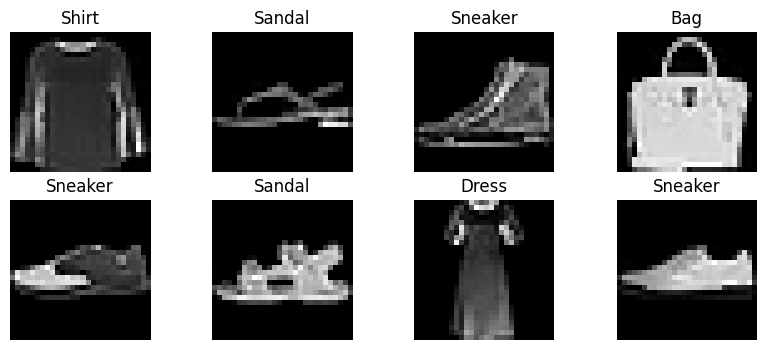

In [22]:
images, labels = next(iter(train_loader_cnn))

plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

Créer un MLP simple pour comparer

In [23]:
class MLPImage(nn.Module):
    def __init__(self):
        super(MLPImage, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model_mlp_image = MLPImage().to(device)

Créer le CNN type LeNet

In [24]:
class CNNLeNet(nn.Module):
    def __init__(self):
        super(CNNLeNet, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_cnn = CNNLeNet().to(device)
print(model_cnn)

CNNLeNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


Entraînement du CNN

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

epochs = 5
cnn_losses = []

for epoch in range(epochs):
    model_cnn.train()
    total_loss = 0

    for images, labels in train_loader_cnn:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    cnn_losses.append(total_loss)

    print(f"Epoch {epoch+1}/{epochs} - Loss : {total_loss:.4f}")

Epoch 1/5 - Loss : 436.8881
Epoch 2/5 - Loss : 290.7044
Epoch 3/5 - Loss : 246.8198
Epoch 4/5 - Loss : 218.9255
Epoch 5/5 - Loss : 198.0057


Courbe de perte CNN

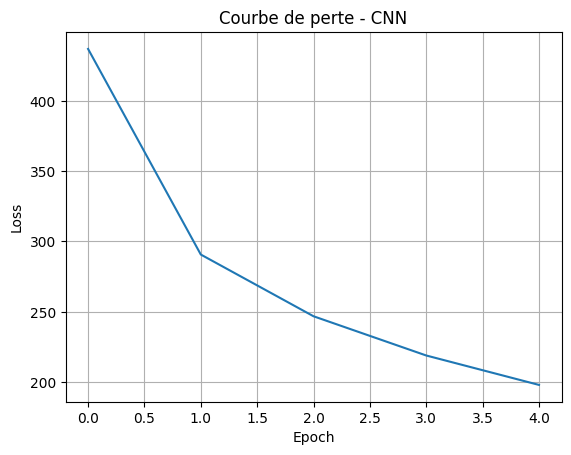

In [26]:
plt.plot(cnn_losses)
plt.title("Courbe de perte - CNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

Évaluation du CNN

In [27]:
model_cnn.eval()

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_cnn:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cnn(images)
        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy_cnn = correct / total

print("Accuracy CNN :", accuracy_cnn)
print(classification_report(all_labels, all_preds, target_names=classes))

Accuracy CNN : 0.9103
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.86      0.86      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.88      0.84      0.86      1000
       Dress       0.88      0.94      0.91      1000
        Coat       0.83      0.88      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.76      0.73      0.75      1000
     Sneaker       0.93      0.99      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



Matrice de confusion

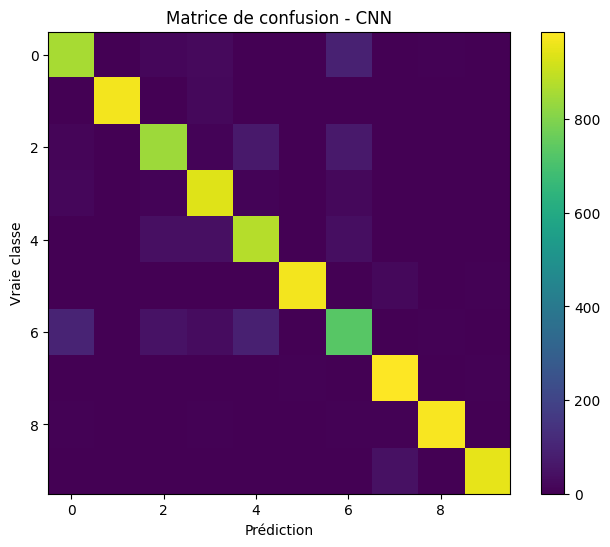

In [28]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Matrice de confusion - CNN")
plt.colorbar()
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.show()

Visualisation des cartes de caractéristiques

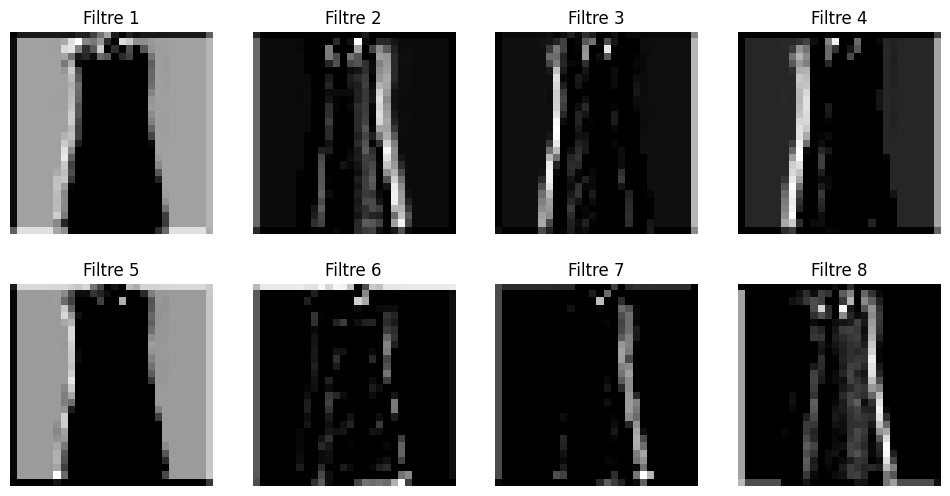

In [29]:
model_cnn.eval()

image = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    feature_maps = model_cnn.relu(model_cnn.conv1(image))

feature_maps = feature_maps.cpu().squeeze()

plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(feature_maps[i], cmap="gray")
    plt.title(f"Filtre {i+1}")
    plt.axis("off")

plt.show()

Texte d’analyse critique
Dans cette deuxième partie, nous avons utilisé un CNN pour classifier les images du dataset Fashion-MNIST.
Contrairement au MLP, le CNN conserve la structure spatiale des images grâce aux couches convolutionnelles.
Les filtres permettent d’extraire automatiquement des caractéristiques locales comme les contours, les formes et les textures.
Le pooling réduit la taille des cartes de caractéristiques tout en gardant les informations importantes.
Les résultats montrent que le CNN est plus adapté aux images qu’un MLP, car il exploite la localité et le partage des poids.

**Partie III — RNN, LSTM, GRU et Seq2Seq**

Importations

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

Créer un petit dataset textuel

In [31]:
texts = [
    "this movie is very good",
    "i love this film",
    "amazing story and great acting",
    "excellent movie with good actors",
    "this film is wonderful",
    "i really enjoyed this movie",

    "this movie is very bad",
    "i hate this film",
    "boring story and bad acting",
    "terrible movie with bad actors",
    "this film is awful",
    "i really disliked this movie"
]

labels = [
    1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0
]

Construire le vocabulaire

In [32]:
words = set()

for text in texts:
    for word in text.split():
        words.add(word)

vocab = {word: i+1 for i, word in enumerate(words)}
vocab["<PAD>"] = 0

print("Vocabulaire :")
print(vocab)
print("Taille du vocabulaire :", len(vocab))

Vocabulaire :
{'excellent': 1, 'awful': 2, 'and': 3, 'disliked': 4, 'movie': 5, 'i': 6, 'enjoyed': 7, 'amazing': 8, 'story': 9, 'love': 10, 'with': 11, 'terrible': 12, 'really': 13, 'actors': 14, 'film': 15, 'this': 16, 'hate': 17, 'bad': 18, 'acting': 19, 'very': 20, 'boring': 21, 'wonderful': 22, 'great': 23, 'is': 24, 'good': 25, '<PAD>': 0}
Taille du vocabulaire : 26


Encoder les textes

In [33]:
def encode_text(text, vocab, max_len=7):
    tokens = []

    for word in text.split():
        tokens.append(vocab[word])

    if len(tokens) < max_len:
        tokens += [0] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]

    return tokens

In [34]:
X_encoded = []

for text in texts:
    X_encoded.append(encode_text(text, vocab))

X_seq = torch.tensor(X_encoded, dtype=torch.long)
y_seq = torch.tensor(labels, dtype=torch.long)

print(X_seq)
print(y_seq)

tensor([[16,  5, 24, 20, 25,  0,  0],
        [ 6, 10, 16, 15,  0,  0,  0],
        [ 8,  9,  3, 23, 19,  0,  0],
        [ 1,  5, 11, 25, 14,  0,  0],
        [16, 15, 24, 22,  0,  0,  0],
        [ 6, 13,  7, 16,  5,  0,  0],
        [16,  5, 24, 20, 18,  0,  0],
        [ 6, 17, 16, 15,  0,  0,  0],
        [21,  9,  3, 18, 19,  0,  0],
        [12,  5, 11, 18, 14,  0,  0],
        [16, 15, 24,  2,  0,  0,  0],
        [ 6, 13,  4, 16,  5,  0,  0]])
tensor([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])


DataLoader

In [35]:
dataset_seq = TensorDataset(X_seq, y_seq)
loader_seq = DataLoader(dataset_seq, batch_size=2, shuffle=True)

Modèle 1 : RNN simple

Implémenter le RNN

In [36]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(RNNModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.rnn(x)
        hidden = hidden[-1]
        x = self.fc(hidden)
        return x

Modèle 2 : LSTM

Implémenter le LSTM

In [37]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        hidden = hidden[-1]
        x = self.fc(hidden)
        return x

Modèle 3 : GRU

Implémenter le GRU

In [38]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(GRUModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.gru(x)
        hidden = hidden[-1]
        x = self.fc(hidden)
        return x

Fonction d’entraînement avec Gradient Clipping

In [39]:
def train_sequence_model(model, loader, epochs=30):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)

        print(f"Epoch {epoch+1}/{epochs} - Loss : {total_loss:.4f}")

    return losses

Entraîner RNN

In [40]:
rnn_model = RNNModel(
    vocab_size=len(vocab),
    embedding_dim=16,
    hidden_dim=32,
    output_dim=2
)

loss_rnn = train_sequence_model(rnn_model, loader_seq, epochs=30)

Epoch 1/30 - Loss : 4.2820
Epoch 2/30 - Loss : 4.2251
Epoch 3/30 - Loss : 4.1427
Epoch 4/30 - Loss : 4.0781
Epoch 5/30 - Loss : 4.0707
Epoch 6/30 - Loss : 4.0416
Epoch 7/30 - Loss : 4.0043
Epoch 8/30 - Loss : 3.9695
Epoch 9/30 - Loss : 3.9379
Epoch 10/30 - Loss : 3.8863
Epoch 11/30 - Loss : 3.8516
Epoch 12/30 - Loss : 3.7602
Epoch 13/30 - Loss : 3.6648
Epoch 14/30 - Loss : 3.5727
Epoch 15/30 - Loss : 3.4718
Epoch 16/30 - Loss : 3.3297
Epoch 17/30 - Loss : 3.2341
Epoch 18/30 - Loss : 3.0459
Epoch 19/30 - Loss : 2.8689
Epoch 20/30 - Loss : 2.6664
Epoch 21/30 - Loss : 2.4471
Epoch 22/30 - Loss : 2.2423
Epoch 23/30 - Loss : 1.9682
Epoch 24/30 - Loss : 1.7648
Epoch 25/30 - Loss : 1.5282
Epoch 26/30 - Loss : 1.2578
Epoch 27/30 - Loss : 0.9610
Epoch 28/30 - Loss : 0.7611
Epoch 29/30 - Loss : 0.5844
Epoch 30/30 - Loss : 0.4630


Entraîner LSTM

In [41]:
gru_model = GRUModel(
    vocab_size=len(vocab),
    embedding_dim=16,
    hidden_dim=32,
    output_dim=2
)

loss_gru = train_sequence_model(gru_model, loader_seq, epochs=30)

Epoch 1/30 - Loss : 4.1484
Epoch 2/30 - Loss : 4.1016
Epoch 3/30 - Loss : 4.0654
Epoch 4/30 - Loss : 4.0060
Epoch 5/30 - Loss : 3.9605
Epoch 6/30 - Loss : 3.9349
Epoch 7/30 - Loss : 3.8956
Epoch 8/30 - Loss : 3.8323
Epoch 9/30 - Loss : 3.7845
Epoch 10/30 - Loss : 3.6892
Epoch 11/30 - Loss : 3.5961
Epoch 12/30 - Loss : 3.4825
Epoch 13/30 - Loss : 3.3845
Epoch 14/30 - Loss : 3.2171
Epoch 15/30 - Loss : 3.0629
Epoch 16/30 - Loss : 2.8678
Epoch 17/30 - Loss : 2.6062
Epoch 18/30 - Loss : 2.3541
Epoch 19/30 - Loss : 2.0824
Epoch 20/30 - Loss : 1.8267
Epoch 21/30 - Loss : 1.5508
Epoch 22/30 - Loss : 1.3303
Epoch 23/30 - Loss : 1.1150
Epoch 24/30 - Loss : 0.9158
Epoch 25/30 - Loss : 0.7880
Epoch 26/30 - Loss : 0.7158
Epoch 27/30 - Loss : 0.6376
Epoch 28/30 - Loss : 0.5315
Epoch 29/30 - Loss : 0.4372
Epoch 30/30 - Loss : 0.3214


In [43]:
loss_rnn = train_sequence_model(rnn_model, loader_seq)

Epoch 1/30 - Loss : 0.4621
Epoch 2/30 - Loss : 0.2742
Epoch 3/30 - Loss : 0.2323
Epoch 4/30 - Loss : 0.1810
Epoch 5/30 - Loss : 0.1341
Epoch 6/30 - Loss : 0.1010
Epoch 7/30 - Loss : 0.0854
Epoch 8/30 - Loss : 0.0679
Epoch 9/30 - Loss : 0.0556
Epoch 10/30 - Loss : 0.0484
Epoch 11/30 - Loss : 0.0419
Epoch 12/30 - Loss : 0.0375
Epoch 13/30 - Loss : 0.0327
Epoch 14/30 - Loss : 0.0296
Epoch 15/30 - Loss : 0.0266
Epoch 16/30 - Loss : 0.0246
Epoch 17/30 - Loss : 0.0226
Epoch 18/30 - Loss : 0.0207
Epoch 19/30 - Loss : 0.0189
Epoch 20/30 - Loss : 0.0174
Epoch 21/30 - Loss : 0.0162
Epoch 22/30 - Loss : 0.0151
Epoch 23/30 - Loss : 0.0142
Epoch 24/30 - Loss : 0.0134
Epoch 25/30 - Loss : 0.0126
Epoch 26/30 - Loss : 0.0119
Epoch 27/30 - Loss : 0.0113
Epoch 28/30 - Loss : 0.0107
Epoch 29/30 - Loss : 0.0101
Epoch 30/30 - Loss : 0.0097


In [45]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = hidden[-1]

        x = self.fc(hidden)

        return x

In [46]:
lstm_model = LSTMModel(
    vocab_size=len(vocab),
    embedding_dim=16,
    hidden_dim=32,
    output_dim=2
)

In [47]:
print(lstm_model)

LSTMModel(
  (embedding): Embedding(26, 16)
  (lstm): LSTM(16, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


In [48]:
loss_lstm = train_sequence_model(
    lstm_model,
    loader_seq,
    epochs=30
)

Epoch 1/30 - Loss : 4.1796
Epoch 2/30 - Loss : 4.1411
Epoch 3/30 - Loss : 4.1422
Epoch 4/30 - Loss : 4.1318
Epoch 5/30 - Loss : 4.1064
Epoch 6/30 - Loss : 4.0920
Epoch 7/30 - Loss : 4.0685
Epoch 8/30 - Loss : 4.0451
Epoch 9/30 - Loss : 4.0099
Epoch 10/30 - Loss : 3.9672
Epoch 11/30 - Loss : 3.9017
Epoch 12/30 - Loss : 3.8170
Epoch 13/30 - Loss : 3.6944
Epoch 14/30 - Loss : 3.5289
Epoch 15/30 - Loss : 3.2889
Epoch 16/30 - Loss : 3.0075
Epoch 17/30 - Loss : 2.7257
Epoch 18/30 - Loss : 2.4717
Epoch 19/30 - Loss : 2.1221
Epoch 20/30 - Loss : 1.8020
Epoch 21/30 - Loss : 1.3888
Epoch 22/30 - Loss : 1.1502
Epoch 23/30 - Loss : 0.8056
Epoch 24/30 - Loss : 0.5018
Epoch 25/30 - Loss : 0.3268
Epoch 26/30 - Loss : 0.2256
Epoch 27/30 - Loss : 0.1521
Epoch 28/30 - Loss : 0.1163
Epoch 29/30 - Loss : 0.0941
Epoch 30/30 - Loss : 0.0783


In [49]:
print("vocab" in globals())
print("loader_seq" in globals())
print("train_sequence_model" in globals())
print("LSTMModel" in globals())

True
True
True
True


Comparer les courbes de perte

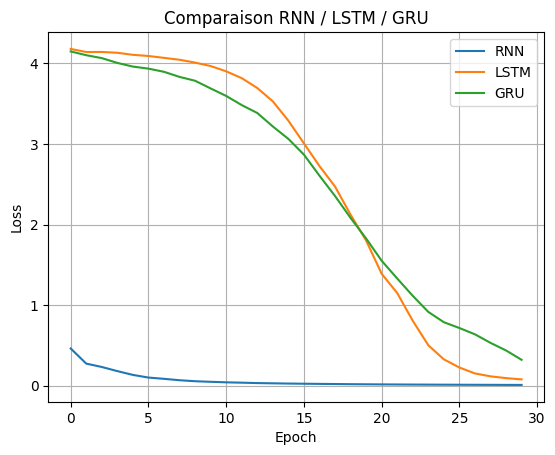

In [50]:
plt.plot(loss_rnn, label="RNN")
plt.plot(loss_lstm, label="LSTM")
plt.plot(loss_gru, label="GRU")

plt.title("Comparaison RNN / LSTM / GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Fonction de prédiction

In [51]:
def predict_sentiment(model, sentence):
    model.eval()

    encoded = encode_text(sentence, vocab)
    encoded = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        output = model(encoded)
        prediction = torch.argmax(output, dim=1).item()

    if prediction == 1:
        return "Avis positif"
    else:
        return "Avis négatif"

Tester les modèles

In [52]:
test_sentence = "this movie is good"

print("Phrase :", test_sentence)
print("RNN :", predict_sentiment(rnn_model, test_sentence))
print("LSTM :", predict_sentiment(lstm_model, test_sentence))
print("GRU :", predict_sentiment(gru_model, test_sentence))

Phrase : this movie is good
RNN : Avis positif
LSTM : Avis positif
GRU : Avis positif


**Partie Seq2Seq simplifiée**

Dataset traduction simple

In [53]:
pairs = [
    ("je suis etudiante", "i am student"),
    ("je suis heureuse", "i am happy"),
    ("il est professeur", "he is teacher"),
    ("elle est intelligente", "she is smart")
]

Vocabulaire source et cible

In [54]:
source_words = set()
target_words = set()

for src, tgt in pairs:
    for word in src.split():
        source_words.add(word)
    for word in tgt.split():
        target_words.add(word)

source_vocab = {word: i+1 for i, word in enumerate(source_words)}
source_vocab["<PAD>"] = 0

target_vocab = {word: i+3 for i, word in enumerate(target_words)}
target_vocab["<PAD>"] = 0
target_vocab["<SOS>"] = 1
target_vocab["<EOS>"] = 2

index_to_target = {i: word for word, i in target_vocab.items()}

print("Source vocab :", source_vocab)
print("Target vocab :", target_vocab)

Source vocab : {'intelligente': 1, 'je': 2, 'etudiante': 3, 'est': 4, 'elle': 5, 'il': 6, 'professeur': 7, 'heureuse': 8, 'suis': 9, '<PAD>': 0}
Target vocab : {'student': 3, 'i': 4, 'smart': 5, 'she': 6, 'happy': 7, 'am': 8, 'is': 9, 'he': 10, 'teacher': 11, '<PAD>': 0, '<SOS>': 1, '<EOS>': 2}


Encoder les phrases Seq2Seq

In [55]:
def encode_sentence(sentence, vocab, max_len=5, add_eos=False):
    tokens = []

    for word in sentence.split():
        tokens.append(vocab[word])

    if add_eos:
        tokens.append(vocab["<EOS>"])

    if len(tokens) < max_len:
        tokens += [0] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]

    return tokens

In [56]:
X_src = []
Y_tgt = []

for src, tgt in pairs:
    X_src.append(encode_sentence(src, source_vocab, max_len=5))
    Y_tgt.append(encode_sentence(tgt, target_vocab, max_len=5, add_eos=True))

X_src = torch.tensor(X_src, dtype=torch.long)
Y_tgt = torch.tensor(Y_tgt, dtype=torch.long)

print(X_src)
print(Y_tgt)

tensor([[2, 9, 3, 0, 0],
        [2, 9, 8, 0, 0],
        [6, 4, 7, 0, 0],
        [5, 4, 1, 0, 0]])
tensor([[ 4,  8,  3,  2,  0],
        [ 4,  8,  7,  2,  0],
        [10,  9, 11,  2,  0],
        [ 6,  9,  5,  2,  0]])


Encoder Seq2Seq

In [57]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super(Decoder, self).__init__()

        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1)
        embedded = self.embedding(input_token)
        output, hidden = self.gru(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

Modèle Seq2Seq

In [58]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = len(target_vocab)

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(device)

        hidden = self.encoder(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input_token, hidden)
            outputs[:, t, :] = output

            input_token = tgt[:, t]

        return outputs

Entraîner Seq2Seq

In [60]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super(Encoder, self).__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)

        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            batch_first=True
        )

    def forward(self, src):
        embedded = self.embedding(src)

        outputs, hidden = self.gru(embedded)

        return hidden

In [61]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super(Decoder, self).__init__()

        self.embedding = nn.Embedding(output_dim, emb_dim)

        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(input_token)

        output, hidden = self.gru(embedded, hidden)

        prediction = self.fc(output.squeeze(1))

        return prediction, hidden

In [62]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):

        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]

        outputs = torch.zeros(
            batch_size,
            tgt_len,
            len(target_vocab)
        ).to(device)

        hidden = self.encoder(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):

            output, hidden = self.decoder(
                input_token,
                hidden
            )

            outputs[:, t] = output

            input_token = tgt[:, t]

        return outputs

In [63]:
encoder = Encoder(
    input_dim=len(source_vocab),
    emb_dim=16,
    hidden_dim=32
)

decoder = Decoder(
    output_dim=len(target_vocab),
    emb_dim=16,
    hidden_dim=32
)

seq2seq_model = Seq2Seq(
    encoder,
    decoder
).to(device)

In [64]:
print("Encoder" in globals())
print("Decoder" in globals())
print("Seq2Seq" in globals())

True
True
True


In [65]:
epochs = 100
seq_losses = []

for epoch in range(epochs):
    seq2seq_model.train()

    src = X_src.to(device)
    tgt = Y_tgt.to(device)

    optimizer.zero_grad()

    output = seq2seq_model(src, tgt)

    output_dim = output.shape[-1]

    output = output[:, 1:].reshape(-1, output_dim)
    tgt = tgt[:, 1:].reshape(-1)

    loss = criterion(output, tgt)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(seq2seq_model.parameters(), max_norm=1.0)

    optimizer.step()

    seq_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss : {loss.item():.4f}")

Epoch 10/100 - Loss : 2.4800
Epoch 20/100 - Loss : 2.4800
Epoch 30/100 - Loss : 2.4800
Epoch 40/100 - Loss : 2.4800
Epoch 50/100 - Loss : 2.4800
Epoch 60/100 - Loss : 2.4800
Epoch 70/100 - Loss : 2.4800
Epoch 80/100 - Loss : 2.4800
Epoch 90/100 - Loss : 2.4800
Epoch 100/100 - Loss : 2.4800


Courbe de perte Seq2Seq

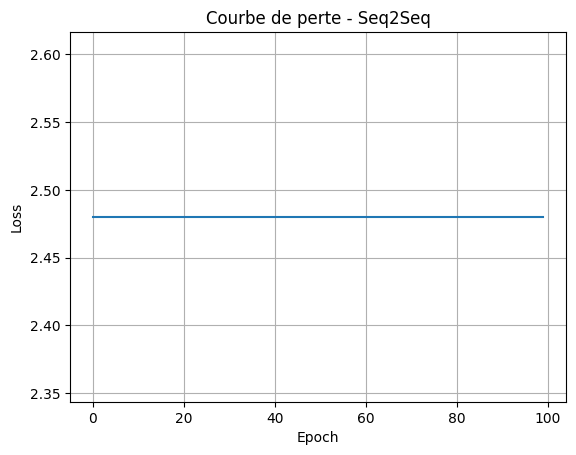

In [66]:
plt.plot(seq_losses)
plt.title("Courbe de perte - Seq2Seq")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

Greedy Decoding

In [67]:
def greedy_decode(model, sentence, max_len=5):
    model.eval()

    src = encode_sentence(sentence, source_vocab, max_len=5)
    src = torch.tensor([src], dtype=torch.long).to(device)

    hidden = model.encoder(src)

    input_token = torch.tensor([target_vocab["<SOS>"]], dtype=torch.long).to(device)

    result = []

    with torch.no_grad():
        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            predicted_token = torch.argmax(output, dim=1).item()

            if predicted_token == target_vocab["<EOS>"]:
                break

            result.append(index_to_target.get(predicted_token, "?"))
            input_token = torch.tensor([predicted_token], dtype=torch.long).to(device)

    return " ".join(result)

In [68]:
print(greedy_decode(seq2seq_model, "je suis etudiante"))

i i she i i


Beam Search simplifié

In [69]:
def beam_search_decode(model, sentence, beam_width=2, max_len=5):
    model.eval()

    src = encode_sentence(sentence, source_vocab, max_len=5)
    src = torch.tensor([src], dtype=torch.long).to(device)

    hidden = model.encoder(src)

    sequences = [([target_vocab["<SOS>"]], 0, hidden)]

    with torch.no_grad():
        for _ in range(max_len):
            all_candidates = []

            for seq, score, hidden_seq in sequences:
                input_token = torch.tensor([seq[-1]], dtype=torch.long).to(device)

                output, new_hidden = model.decoder(input_token, hidden_seq)

                probabilities = torch.softmax(output, dim=1)
                top_probs, top_indices = torch.topk(probabilities, beam_width)

                for i in range(beam_width):
                    token = top_indices[0][i].item()
                    prob = top_probs[0][i].item()

                    candidate = (seq + [token], score - np.log(prob + 1e-9), new_hidden)
                    all_candidates.append(candidate)

            sequences = sorted(all_candidates, key=lambda x: x[1])[:beam_width]

    best_sequence = sequences[0][0]

    words = []

    for token in best_sequence:
        if token in [target_vocab["<SOS>"], target_vocab["<EOS>"], target_vocab["<PAD>"]]:
            continue
        words.append(index_to_target.get(token, "?"))

    return " ".join(words)

In [70]:
print(beam_search_decode(seq2seq_model, "je suis heureuse"))

is teacher is teacher is


BLEU Score simple

In [71]:
from nltk.translate.bleu_score import sentence_bleu
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [72]:
reference = ["i", "am", "happy"]
candidate = greedy_decode(seq2seq_model, "je suis heureuse").split()

bleu = sentence_bleu([reference], candidate)

print("Traduction générée :", candidate)
print("BLEU Score :", bleu)


Traduction générée : ['i', 'i', 'she', 'i', 'i']
BLEU Score : 1.2183324802375697e-231


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

Dans cette troisième partie, nous avons étudié les modèles récurrents RNN, LSTM et GRU pour le traitement de données textuelles.
Le RNN simple permet de prendre en compte l’ordre des mots, mais il présente des limites lorsque les dépendances sont longues.
Le LSTM améliore cette situation grâce à ses mécanismes de portes qui contrôlent la mémoire.
Le GRU propose une architecture plus simple que le LSTM tout en conservant une bonne capacité de mémorisation.
Le gradient clipping permet de limiter l’explosion du gradient pendant l’apprentissage.
Enfin, le modèle Seq2Seq permet de transformer une séquence d’entrée en une séquence de sortie, ce qui est utile pour la traduction automatique.